In [1]:
import numpy as np
import matplotlib.pyplot as plt
# magic word for producing visualizations in notebook
%matplotlib inline
import string
import time

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker


In [3]:
tracker = Tracker().start()

In [4]:
# the IonQ device
device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
supported_gates = device.properties.action['braket.ir.jaqcd.program'].supportedOperations
# print the supported gate set
print('Gate set supported by the IonQ device:\n', supported_gates)
print('\n') 

Gate set supported by the IonQ device:
 ['x', 'y', 'z', 'rx', 'ry', 'rz', 'h', 'cnot', 's', 'si', 't', 'ti', 'v', 'vi', 'xx', 'yy', 'zz', 'swap']




Recall the Hamiltonian embedding of the momentum operator when using the unary code.

We embed
$$
    \hat{P} = -\frac{i}{2h}\begin{pmatrix}
    0 & 1 & 0 & 0\\
    -1 & 0 & \ddots & 0\\
    0 & \ddots & 0 & 1 \\
    0 & 0 & -1 & 0
    \end{pmatrix}
$$
in the full Hamiltonian
$$
    H = \frac{1}{2h}\sum_{i=1}^{n} Y_i + R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right).
$$

In [5]:

from utils import *

In [6]:
# Returns the codewords using unary embedding
def get_codewords_1d_unary(n : int):
    
    codewords = []

    bitstring = [0 for k in range(n)]
    for i in range(n+1):

        codewords.append(np.copy(bitstring))

        if i < n:
            bitstring[i] = 1 - bitstring[i]

    return codewords

In [423]:
n = 10
h = 1 / n
R = 15

T = 0.2
m = 4

S_Y = sum_y(n)
h_coefficients = np.zeros(n)
h_coefficients[0] = 1
h_coefficients[-1] = -1
J = np.zeros((n,n))
for i in range(n-1):
    J[i+1,i] = -1
    
H_penalty = sum_h_z(n, h_coefficients) + sum_J_zz(n, J)
H_full = S_Y / (2 * h) + R * H_penalty



In [424]:
C = get_codewords_1d_unary(n)

In [425]:
H_subspace = np.zeros((n+1,n+1), dtype=np.complex64)


for i in range(n+1):
    for j in range(n+1):
        H_subspace[i,j] = H_full[bitstring_to_int(C[i]), bitstring_to_int(C[j])]

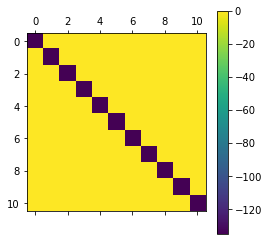

In [426]:
plt.matshow(H_subspace.real)
plt.colorbar()
plt.show()

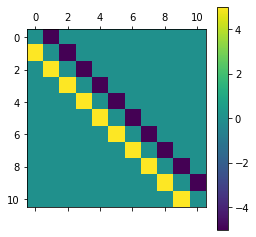

In [427]:
plt.matshow(H_subspace.imag)
plt.colorbar()
plt.show()

We apply Trotterization of the Hamiltonian
$$
    H = \frac{1}{2h}\sum_{i=1}^{n} Y_i + R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right)
$$

To evolve for time $T$, we have
$$
    e^{-iT H} = \left(\exp\left(-i\frac{T}{m} R \left(Z_1 - Z_n - \sum_{i=1}^{n-1} Z_i Z_{i+1}\right)\right) \exp\left(-i\frac{T}{m}\frac{1}{2h}\sum_{i=1}^{n} Y_i\right)\right)^{m} + O(T^2 / m),
$$
so the gate complexity is $O(T^2 / \epsilon)$ for error at most $\epsilon$.

For simplicity, we will start with the initial state being a point mass at the left boundary, i.e.
$$
    \ket{\psi(0)} = \ket{00\dots 0},
$$
so no state preparation is necessary.

In [428]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [429]:
def transport(n, T, m, R):
    h = 1 / n
    # Initial state preparation
    circuit = Circuit()

    for i in range(m):
        # sum of Pauli-y
        circuit.ry(range(n), T / (m * h))
    
        # penalty part
        circuit.rz(0, 2 * T * R / m)
        circuit.rz(n-1, -2 * T * R / m)
        for j in np.arange(0, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / m)
        for j in np.arange(1, n-1, 2):
            circuit.zz(j, j+1, - 2 * T * R / m)
            
    return circuit

def decode_unary(n, bitstring):
    flips = 0
    first_flip = 0
    for i in range(n-1):
        if bitstring[i] != bitstring[i+1]:
            flips += 1
            first_flip = i
    
    if flips >= 2 or (bitstring[0] == 0 and flips == 1):
        return -1
    else:
        if flips == 0:
            if bitstring[0] == 0:
                return 0
            else:
                return n
        elif flips == 1:
            return first_flip + 1

In [430]:

circuit = transport(n, T, m, R = 7)

In [431]:
print(circuit)

print(f"Circuit depth: {circuit.depth}")

T  : |   0    |    1    |    2    |    3    |    4    |    5    |    6    |    7    |    8    |    9    |   10    |   11    |   12    |
                                                                                                                                       
q0 : -Ry(0.50)-Rz(0.70)--ZZ(-0.70)-Ry(0.50)--Rz(0.70)--ZZ(-0.70)-Ry(0.50)--Rz(0.70)--ZZ(-0.70)-Ry(0.50)--Rz(0.70)--ZZ(-0.70)-----------
                         |                             |                             |                             |                   
q1 : -Ry(0.50)-----------ZZ(-0.70)-ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-
                                   |                             |                             |                             |         
q2 : -Ry(0.50)-ZZ(-0.70)-----------ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-Ry(0.50)--ZZ(-0.70)-ZZ(-0.70)-
               |                                

In [432]:
num_shots = 100
task = device.run(circuit, shots=num_shots)

In [433]:
result = task.result()

counts = result.measurement_counts

In [434]:
def get_occurrences(n : int, measurements, num_shots : int):
    occurrences = np.zeros(n+1)
    # occurrences = np.zeros((4,n+1))
    bad_samples = 0
    for i in range(num_shots):
        bitstring = measurements[i]
                
        index = decode_unary(n, bitstring)
        if index >= 0:
            occurrences[index] += 1
                
    print(f"Samples in codeword subspace: {int(np.sum(occurrences))} / {num_shots}")

    return occurrences

In [435]:
occurrences = get_occurrences(n, result.measurements, num_shots=num_shots)
dist = occurrences / np.sum(occurrences)

Samples in codeword subspace: 48 / 100


In [436]:
from scipy.sparse.linalg import expm_multiply
from scipy.sparse import diags

psi_0 = np.zeros((n+1), dtype=np.complex64)
psi_0[0] = 1
psi_0 /= np.linalg.norm(psi_0)

# Transport Hamiltonian
H = diags([-1j * np.ones(n), 1j * np.ones(n)], [1, -1]) / (2 * h)
psi = expm_multiply(-1j * T * H, psi_0)
ideal_dist = np.abs(psi) ** 2

In [437]:
psi_0 = np.zeros(2 ** n, dtype=np.complex64)
psi_0[0] = 1

psi = expm_multiply(-1j * T * H_full, psi_0)

psi_subspace = np.zeros(n+1, dtype=np.complex128)

bitstring = [0 for _ in range(n)]
for i in range(n+1):

    psi_subspace[i] = psi[bitstring_to_int(bitstring)]

    if i < n:
        bitstring[i] = 1 - bitstring[i]

sim_dist = np.abs(psi_subspace) ** 2

print(f"Leakage = {1 - np.sum(sim_dist)}")

Leakage = 0.11585668454758502


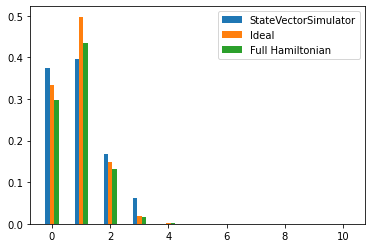

In [438]:
plt.bar(np.array(range(n+1))-0.15, dist, width=0.15, label=f"{device.name}")
plt.bar(np.array(range(n+1)), ideal_dist, width=0.15, label="Ideal")
plt.bar(np.array(range(n+1))+0.15, sim_dist, width=0.15, label="Full Hamiltonian")
plt.legend()
plt.show()

In [77]:
from sympy import Matrix

In [78]:
# A = np.array([[0, 1, 0, 0, 0], [0,0,0,0,1], [-1, 0, 0, 0, 0], [0,0,0, 2, 0], [0,0,-2,0,0]])

A = np.array([[0, 1, 0, 0],[-1, 0, 0, 0], [0,0,0, 2], [0,0,-2,0]])



In [81]:
P, J = Matrix(A).jordan_form()

In [105]:
P_real, P_imag = P.as_real_imag()

In [88]:
evals = J.diagonal()

In [145]:
for i, eval in enumerate(evals):

    checked_evals = {}

    print(eval)
    if eval.is_imaginary:
        gen_evec = P[:,i]
        print(gen_evec)
    else:
        print()

-2*I
Matrix([[0], [0], [I], [1]])
-I
Matrix([[I], [1], [0], [0]])
I
Matrix([[-I], [1], [0], [0]])
2*I
Matrix([[0], [0], [-I], [1]])


In [98]:
gen_evec

Matrix([
[ 0],
[ 0],
[-I],
[ 1]])

In [99]:
gen_evec.C

Matrix([
[0],
[0],
[I],
[1]])

In [102]:
(gen_evec - gen_evec.C) / 1j

Matrix([
[   0],
[   0],
[-2.0],
[   0]])

In [100]:
gen_evec + gen_evec.C

Matrix([
[0],
[0],
[0],
[2]])

In [95]:
A @ gen_evec

Matrix([
[  0],
[  0],
[  2],
[2*I]])

In [ ]:
evec + evec